LABELS: \
Cattle_ID, Breed, Climate_Zone, Management_System, Age_Months, Weight_kg,
Parity, Lactation_Stage, Days_in_Milk, Feed_Type, Feed_Quantity_kg,
Feeding_Frequency, Water_Intake_L, Walking_Distance_km, Grazing_Duration_hrs,
Rumination_Time_hrs, Resting_Hours, Ambient_Temperature_C, Humidity_percent,
Housing_Score, FMD_Vaccine, Brucellosis_Vaccine, HS_Vaccine, BQ_Vaccine,
Anthrax_Vaccine, IBR_Vaccine, BVD_Vaccine, Rabies_Vaccine,
Previous_Week_Avg_Yield, Body_Condition_Score, Milking_Interval_hrs, Date,
Farm_ID, Feed_Quantity_lb, Mastitis, Milk_Yield_L

NOTES:
- Feed_Quanitity_lb and Feed_Quantity_kg are redundant
- Some others may be worth combining (Temperature + Humidity, Rest + Rumination, Vaccines)
- Date may be condensable into season or month
- Non-numeric features: Breed, Climate_Zone, Management_System, Lactation_Stage, Feed_Type, Date, Farm_ID
- Some observations
- Breed: Holstein, Jersey, Guernsey, Brown Swiss
- Climate_Zone: Tropical, Arid, Mediterranean, Subtropical, Continental, Temperate
- Management_System: Intensive, Mixed, Semi_Intensive, Pastoral, Extensive
- Age_Months: [22.5, 142.5]
- Weight_kg: [250, 750]
- Parity: [1, 6]
- Lactation_Stage: Mid, Late, Early
- Days_in_Milk: [0, 365]
- Feed_Type: Concentrates, Crop_Residues, Hay, Mixed_Feed, Silage, Dry_Fodder, Pasture_Grass, Green_Fodder
- Feed_Quantity_kg: [1, 25] <- Check if it correlates with weight.. it should
- Feeding_Frequency: [1, 5]
- Water_Intake_L: [30, 130] <- Check if it correlates with weight.. it should
- Walking_Distance_km: [0.5, 10.5] <- 8k records at 0.5
- Grazing_Duration_hrs: [1, 14] <- 10k records at 1
- Rumination_Time_hrs: [-8, 25] <- Why negative??
- Resting_Hours: [5, 18] <- 12k records at 5.. Check that all records satisfy the total time above is <= 24
- Ambient_Temperature_C: [-12, 47] <- High temperature seems too high, that would imply ambient temperature at around 110+ degrees F
- Humidity_percent: [10, 100] <- 2k at 10, 5k at 100.. seems a little high?
- Housing_Score: [0.27, 1.02] <- This is qualitative, probably should remove if it doesnt correlate well
- Previous_Week_Avg_Yield: [0, 30] <- 8k at 0.. check if it correlates
- Feed_Quantity_lb: <- Check if this matches with Feed_Quantity_kg.
- Milk_Yield_L: Remove records with negative values

In [10]:
from preprocessing import NUM_FEATURES, RecordType, engineer_data, LABEL_COL

import os
if 'experiments' in os.getcwd ():
    os.chdir (os.getcwd () + "/..")
import pandas as pd
print (os.getcwd())

train_data = pd.read_csv ("./data/in/cattle_data_train.csv")
data = pd.read_csv ("./data/in/cattle_data_test.csv")

/home/osten/UTCS/CS-363M/Yield-Regression


In [11]:
print (train_data[LABEL_COL].mean ())
print ("Dupes:")
data[data.duplicated ()]
data.head()
data.info()
data.describe().T

15.589155594329181
Dupes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cattle_ID                40000 non-null  int64  
 1   Breed                    40000 non-null  object 
 2   Climate_Zone             40000 non-null  object 
 3   Management_System        40000 non-null  object 
 4   Age_Months               40000 non-null  int64  
 5   Weight_kg                40000 non-null  float64
 6   Parity                   40000 non-null  int64  
 7   Lactation_Stage          40000 non-null  object 
 8   Days_in_Milk             40000 non-null  int64  
 9   Feed_Type                40000 non-null  object 
 10  Feed_Quantity_kg         37985 non-null  float64
 11  Feeding_Frequency        40000 non-null  int64  
 12  Water_Intake_L           40000 non-null  float64
 13  Walking_Distance_km      40000 non-null  float64
 

,count,mean,std,min,25%,50%,75%,max
Cattle_ID,40000.0,20000.500000,11547.149720,1.000000,10000.750000,20000.500000,30000.250000,40000.000000
Age_Months,40000.0,83.263900,34.613224,24.000000,53.000000,83.000000,113.000000,143.000000
Weight_kg,40000.0,501.134588,143.395426,250.000000,377.500000,501.300000,624.500000,750.000000
Parity,40000.0,3.500175,1.704677,1.000000,2.000000,4.000000,5.000000,6.000000
Days_in_Milk,40000.0,183.146600,105.351685,1.000000,92.000000,183.000000,275.000000,364.000000
Feed_Quantity_kg,37985.0,12.015819,3.952974,2.274356,9.316865,12.033033,14.692782,25.469967
Feeding_Frequency,40000.0,3.008675,1.409077,1.000000,2.000000,3.000000,4.000000,5.000000
Water_Intake_L,40000.0,79.892539,14.956080,18.953859,69.822227,79.877772,89.900649,157.259638
Walking_Distance_km,40000.0,4.050308,1.923811,0.500000,2.670000,4.020000,5.360000,12.000000
Grazing_Duration_hrs,40000.0,6.037943,2.867362,1.000000,4.000000,6.000000,8.000000,14.000000


### Season Exploration

Missing Counts:
Feed_Quantity_kg: 2015
Housing_Score: 1221
Feed_Quantity_lb: 2015
High yield samples: 2102 / 210000


Text(0.5, 1.0, 'Average Milk Yield by Day of Year (Colored by Season)')

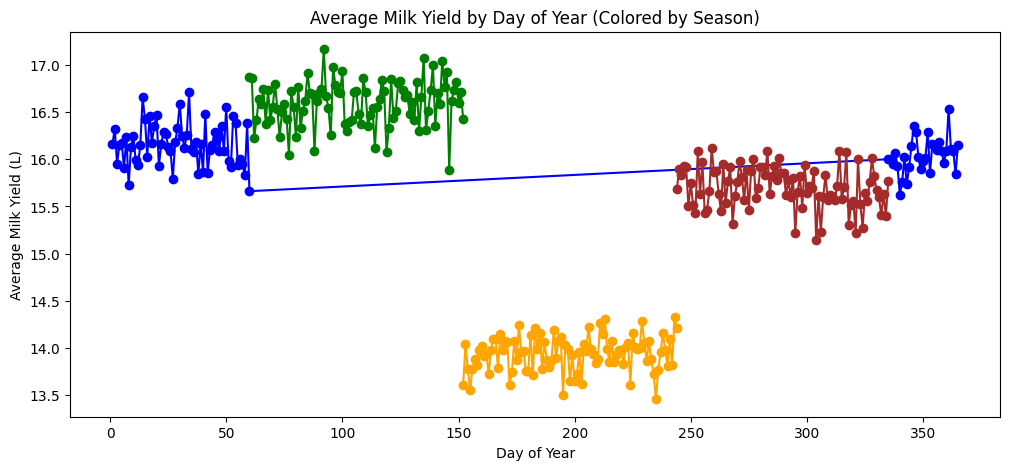

In [12]:
# Count NaNs
print ("Missing Counts:")
for col in data.columns:
    missing_count = data[col].isna ().sum ()
    if missing_count:
        print(f"{col}: {missing_count}")

high_yield_train = train_data[train_data['Milk_Yield_L'] > 30]
print(f"High yield samples: {len(high_yield_train)} / {len(train_data)}")

import matplotlib.pyplot as plt

# Ensure Date column is datetime
train_data["Date"] = pd.to_datetime(train_data["Date"])
train_data["DayOfYear"] = train_data["Date"].dt.dayofyear

# Define season mapping
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

# Map each row to a season
train_data["Season"] = train_data["Date"].dt.month.apply(month_to_season)

# Compute daily average milk yield, keeping season info
daily_avg = train_data.groupby(["DayOfYear", "Season"])["Milk_Yield_L"].mean().reset_index()

# Define colors for seasons
season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "orange",
    "Fall": "brown"
}

# Plot each season separately
plt.figure(figsize=(12,5))
for season, color in season_colors.items():
    season_data = daily_avg[daily_avg["Season"] == season]
    plt.plot(season_data["DayOfYear"], season_data["Milk_Yield_L"], marker="o", color=color, label=season)

plt.xlabel("Day of Year")
plt.ylabel("Average Milk Yield (L)")
plt.title("Average Milk Yield by Day of Year (Colored by Season)")



### Vaccine Exploration

In [13]:
ibr_count = len (train_data[train_data['IBR_Vaccine'] == True])
anthrax_count = len (train_data[train_data['Anthrax_Vaccine'] == True])
rabies_count = len (train_data[train_data['Rabies_Vaccine'] == True])

ibr = train_data[train_data['Rabies_Vaccine'] == True]
print (len (ibr))

# Count cows with at least one of the three useful vaccines
at_least_one = train_data[
    (train_data['IBR_Vaccine'] == True) | 
    (train_data['Anthrax_Vaccine'] == True) | 
    (train_data['Rabies_Vaccine'] == True)
]
print(f"Cows with at least one vaccine: {len(at_least_one)}")
print(f"Percentage: {len(at_least_one) / len(train_data) * 100:.1f}%")

# Overlap analysis
ibr_anthrax = len(train_data[(train_data['IBR_Vaccine'] == True) & (train_data['Anthrax_Vaccine'] == True)])
ibr_rabies = len(train_data[(train_data['IBR_Vaccine'] == True) & (train_data['Rabies_Vaccine'] == True)])
anthrax_rabies = len(train_data[(train_data['Anthrax_Vaccine'] == True) & (train_data['Rabies_Vaccine'] == True)])
all_three = len(train_data[
    (train_data['IBR_Vaccine'] == True) & 
    (train_data['Anthrax_Vaccine'] == True) & 
    (train_data['Rabies_Vaccine'] == True)
])

print(f"IBR only: {ibr_count}")
print(f"Anthrax only: {anthrax_count}")
print(f"Rabies only: {rabies_count}")
print(f"IBR + Anthrax: {ibr_anthrax}")
print(f"IBR + Rabies: {ibr_rabies}")
print(f"Anthrax + Rabies: {anthrax_rabies}")
print(f"All three: {all_three}")

126173
Cows with at least one vaccine: 196610
Percentage: 93.6%
IBR only: 125751
Anthrax only: 126080
Rabies only: 126173
IBR + Anthrax: 75517
IBR + Rabies: 75533
Anthrax + Rabies: 75606
All three: 45262


### High Correlation Stats

In [14]:
data = engineer_data (data)
keep_num_features = [ft for ft, t in NUM_FEATURES.items () if t == RecordType.KEEP]

for feature in keep_num_features:
    if feature in data.columns:
        print (f"\n{feature}:")
        print ("-" * 40)
        stats = data[feature].describe ()
        print (f"  Mean:    {stats['mean']:.4f}")
        print (f"  Std:     {stats['std']:.4f}")
        print (f"  Range:   {stats['min']:.4f} | {stats['25%']:.4f} | {stats['50%']:.4f} | {stats['75%']:.4f} | {stats['max']:.4f}")
        print (f"  Missing: {data[feature].isna ().sum ()}")


Age_Months:
----------------------------------------
  Mean:    83.2639
  Std:     34.6132
  Range:   24.0000 | 53.0000 | 83.0000 | 113.0000 | 143.0000
  Missing: 0

Weight_kg:
----------------------------------------
  Mean:    501.1346
  Std:     143.3954
  Range:   250.0000 | 377.5000 | 501.3000 | 624.5000 | 750.0000
  Missing: 0

Parity:
----------------------------------------
  Mean:    3.5002
  Std:     1.7047
  Range:   1.0000 | 2.0000 | 4.0000 | 5.0000 | 6.0000
  Missing: 0

Days_in_Milk:
----------------------------------------
  Mean:    183.1466
  Std:     105.3517
  Range:   1.0000 | 92.0000 | 183.0000 | 275.0000 | 364.0000
  Missing: 0

Feed_Quantity_kg:
----------------------------------------
  Mean:    12.0167
  Std:     3.8521
  Range:   2.2744 | 9.4633 | 12.0330 | 14.5191 | 25.4700
  Missing: 0

Water_Intake_L:
----------------------------------------
  Mean:    79.8936
  Std:     14.9459
  Range:   30.0000 | 69.8222 | 79.8778 | 89.9006 | 140.0000
  Missing: 0

Ambi

### Correlation Exploration

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load data
data = pd.read_csv("./data/in/cattle_data_train.csv")
data['Breed'] = data['Breed'].replace({'Holstien': 'Holstein', 'Brown Swiss ': 'Brown Swiss'})

# Create output directory
os.makedirs("./experiments/plots/feature_analysis", exist_ok=True)

TARGET = "Milk_Yield_L"

data["THI"] = (0.8 * data["Ambient_Temperature_C"]) + \
               (data["Humidity_percent"] / 100) * (data["Ambient_Temperature_C"] - 14.4) + \
               46.4
data["THI_Stress_Level"] = 0
data.loc[(data["THI"] >= 72) & (data["THI"] < 78), "THI_Stress_Level"] = 1
data.loc[(data["THI"] >= 78) & (data["THI"] < 88), "THI_Stress_Level"] = 2
data.loc[data["THI"] >= 88, "THI_Stress_Level"] = 3

# Identify numeric and categorical columns
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric if present
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

# Also treat Date as categorical if present
if 'Date' in numeric_cols:
    numeric_cols.remove('Date')
    if 'Date' not in categorical_cols:
        categorical_cols.append('Date')

print(f"Found {len(numeric_cols)} numeric features and {len(categorical_cols)} categorical features")
print(f"Plotting each feature vs {TARGET}...\n")

# ============================================================================  
# NUMERIC FEATURES - Scatter Plots (Mean + Median per bin) + Counts
# ============================================================================  
for col in numeric_cols:
    # Skip if all NaN
    if data[col].isna().all():
        print(f"Skipping {col} - all NaN")
        continue

    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14), 
                                         gridspec_kw={'height_ratios': [2, 2, 1]})

    # Separate missing vs non-missing
    has_data = data[data[col].notna()]
    missing_data = data[data[col].isna()]

    if len(has_data) > 0:
        # Plot all data points (top subplot)
        ax1.scatter(has_data[col], has_data[TARGET], alpha=0.3, 
                   color='gray', s=20, edgecolor='none', 
                   label=f'All data (n={len(has_data)})')
        
        # Bin numeric feature into 100 equal-width bins
        has_data = has_data.copy()
        has_data['x_bin'] = pd.cut(has_data[col], bins=100)

        # Compute mean & median per bin
        stats = has_data.groupby('x_bin', observed=True)[TARGET].agg(['mean', 'median', 'count']).reset_index()

        # Use bin midpoints for x-axis
        stats['x_mid'] = stats['x_bin'].apply(lambda x: x.mid)

        # Plot mean & median on scatter plot (top subplot)
        ax1.scatter(stats['x_mid'], stats['mean'], color='blue', 
                   label='Bin Mean', s=60, edgecolor='k', linewidth=0.5, zorder=5)
        ax1.scatter(stats['x_mid'], stats['median'], color='red', 
                   label='Bin Median', s=60, edgecolor='k', linewidth=0.5, zorder=5)

        # Plot mean & median (middle subplot)
        ax2.scatter(stats['x_mid'], stats['mean'], color='blue', 
                   label='Mean', s=60, edgecolor='k', linewidth=0.3)
        ax2.scatter(stats['x_mid'], stats['median'], color='red', 
                   label='Median', s=60, edgecolor='k', linewidth=0.3)

        # Plot counts (bottom subplot)
        ax3.bar(stats['x_mid'], stats['count'], 
               width=stats['x_bin'].apply(lambda x: x.length).iloc[0] * 0.9,
               color='steelblue', edgecolor='k', linewidth=0.3, alpha=0.7)

    # Optional: plot missing data
    if len(missing_data) > 0:
        # Missing data on scatter plot
        ax1.scatter([has_data[col].min()] * len(missing_data), 
                   missing_data[TARGET], marker='x', 
                   color='red', s=50, alpha=0.5,
                   label=f'Missing {col} (n={len(missing_data)})')
        
        # Missing data stats on bin plot
        ax2.scatter([0], [missing_data[TARGET].median()], marker='^', 
                   color='red', s=100, 
                   label=f'Missing median')
        ax2.scatter([0], [missing_data[TARGET].mean()], marker='^', 
                   color='blue', s=100, 
                   label=f'Missing mean')
        
        # Add missing count to bottom plot
        ax3.bar([0], [len(missing_data)], width=0.5, 
               color='red', edgecolor='k', linewidth=0.5, alpha=0.7,
               label=f'Missing')

    # Format top subplot (scatter)
    ax1.set_ylabel(TARGET, fontsize=12)
    ax1.set_title(f"{col} vs {TARGET} (all data + bin statistics)", fontsize=14)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Format middle subplot (bin stats)
    ax2.set_ylabel(TARGET, fontsize=12)
    ax2.set_title(f"Binned mean & median", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Format bottom subplot
    ax3.set_xlabel(col, fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    if len(missing_data) > 0:
        ax3.legend()

    plt.tight_layout()

    # Save figure
    safe_filename = col.replace("/", "_").replace(" ", "_")
    plt.savefig(f"./experiments/plots/feature_analysis/{safe_filename}_vs_{TARGET}.png", dpi=100)
    plt.close()

    print(f"✓ Saved {col}")

# ============================================================================  
# CATEGORICAL FEATURES - Mean & Median Points + Counts
# ============================================================================  
for col in categorical_cols:
    # Skip if all NaN
    if data[col].isna().all():
        print(f"Skipping {col} - all NaN")
        continue

    # Compute mean, median & count per category
    stats = data.groupby(col, observed=True)[TARGET].agg(['mean', 'median', 'count']).reset_index()
    stats = stats.sort_values('mean', ascending=False)

    # Limit to top 20 categories
    if len(stats) > 20:
        stats = stats.head(20)
        title_suffix = " (Top 20)"
    else:
        title_suffix = ""

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                     gridspec_kw={'height_ratios': [2, 1]})
    
    x_pos = np.arange(len(stats))

    # Plot mean & median (top subplot)
    ax1.scatter(x_pos, stats['mean'], color='blue', s=100, 
               label='Mean', edgecolor='k')
    ax1.scatter(x_pos, stats['median'], color='red', s=100, 
               label='Median', edgecolor='k')

    # Plot counts (bottom subplot)
    ax2.bar(x_pos, stats['count'], color='steelblue', 
           edgecolor='k', linewidth=0.5, alpha=0.7)

    # Format top subplot
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([])  # Remove x labels from top plot
    ax1.set_ylabel(TARGET, fontsize=12)
    ax1.set_title(f"{col} vs {TARGET}{title_suffix}", fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Format bottom subplot
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(stats[col], rotation=45, ha='right')
    ax2.set_xlabel(col, fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    # Save figure
    safe_filename = col.replace("/", "_").replace(" ", "_")
    plt.savefig(f"./experiments/plots/feature_analysis/{safe_filename}_vs_{TARGET}.png", dpi=100)
    plt.close()

    print(f"✓ Saved {col}")

print(f"\n✅ All plots saved to ./experiments/plots/feature_analysis/")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("FEATURE SUMMARY")
print("="*80)

print(f"\nTarget ({TARGET}) Statistics:")
print(data[TARGET].describe())

print(f"\nMissing Data Summary:")
missing_summary = data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("No missing data!")

print("\n" + "="*80)

Found 29 numeric features and 8 categorical features
Plotting each feature vs Milk_Yield_L...

✓ Saved Age_Months
✓ Saved Weight_kg
✓ Saved Parity
✓ Saved Days_in_Milk
✓ Saved Feed_Quantity_kg
✓ Saved Feeding_Frequency
✓ Saved Water_Intake_L
✓ Saved Walking_Distance_km
✓ Saved Grazing_Duration_hrs
✓ Saved Rumination_Time_hrs
✓ Saved Resting_Hours
✓ Saved Ambient_Temperature_C
✓ Saved Humidity_percent
✓ Saved Housing_Score
✓ Saved FMD_Vaccine
✓ Saved Brucellosis_Vaccine
✓ Saved HS_Vaccine
✓ Saved BQ_Vaccine
✓ Saved Anthrax_Vaccine
✓ Saved IBR_Vaccine
✓ Saved BVD_Vaccine
✓ Saved Rabies_Vaccine
✓ Saved Previous_Week_Avg_Yield
✓ Saved Body_Condition_Score
✓ Saved Milking_Interval_hrs
✓ Saved Feed_Quantity_lb
✓ Saved Mastitis
✓ Saved THI
✓ Saved THI_Stress_Level
✓ Saved Cattle_ID
✓ Saved Breed
✓ Saved Climate_Zone
✓ Saved Management_System
✓ Saved Lactation_Stage
✓ Saved Feed_Type
✓ Saved Date
✓ Saved Farm_ID

✅ All plots saved to ./experiments/plots/feature_analysis/

FEATURE SUMMARY

Targ

In [ ]:
# ============================================================================
# INTERACTION FEATURES - Scatter Plots (a * b)
# ============================================================================
print("\nGenerating interaction feature plots (a * b)...\n")

num_cols = numeric_cols[:]  # avoid modifying original list
n = len(num_cols)

for i in range(n):
    for j in range(i + 1, n):
        col_a = num_cols[i]
        col_b = num_cols[j]

        # Skip if one column is all NaN
        if data[col_a].isna().all() or data[col_b].isna().all():
            print(f"Skipping {col_a} × {col_b} (one feature all NaN)")
            continue

        # Compute interaction
        interaction = data[col_a] * data[col_b]

        plt.figure(figsize=(10, 6))

        # Separate missing vs non-missing
        valid_mask = ~interaction.isna()
        has_data = data[valid_mask]
        missing_mask = interaction.isna()
        missing_data = data[missing_mask]

        if len(has_data) > 0:
            plt.scatter(
                interaction[valid_mask],
                has_data[TARGET],
                alpha=0.3,
                edgecolor='k',
                linewidth=0.3,
                label=f'Has Data (n={len(has_data)})',
                color='purple'
            )

        if len(missing_data) > 0:
            plt.scatter(
                [0] * len(missing_data),
                missing_data[TARGET],
                alpha=0.3,
                edgecolor='k',
                linewidth=0.3,
                marker='^',
                label=f'Missing Interaction (n={len(missing_data)})',
                color='red'
            )

        plt.xlabel(f"{col_a} × {col_b}", fontsize=12)
        plt.ylabel(TARGET, fontsize=12)
        plt.title(f"{col_a} × {col_b} Interaction vs {TARGET}", fontsize=14)
        plt.grid(True, alpha=0.3)

        if len(missing_data) > 0:
            plt.legend()

        plt.tight_layout()

        # Save plot
        safe_a = col_a.replace("/", "_").replace(" ", "_")
        safe_b = col_b.replace("/", "_").replace(" ", "_")
        fname = f"./experiments/plots/feature_analysis/interactions/{safe_a}_x_{safe_b}_interaction_vs_{TARGET}.png"
        plt.savefig(fname, dpi=100)
        plt.close()

        print(f"✓ Saved interaction: {col_a} × {col_b}")

print("\n✅ All interaction plots saved.\n")

### Distribution Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
import os

train_path = './data/in/cattle_data_train.csv'
test_path = './data/in/cattle_data_test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# Keep only common columns
common_cols = [col for col in train.columns if col in test.columns]
train = train[common_cols]
test = test[common_cols]

# Separate numeric and categorical
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

print("\nNumeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

os.makedirs("./experiments/plots/distribution_plots", exist_ok=True)

print("\n=== NUMERIC FEATURE DISTRIBUTION COMPARISON ===")
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(train[col], label="Train", fill=True)
    sns.kdeplot(test[col], label="Test", fill=True)
    plt.title(f"Distribution of {col} (Train vs Test)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"./experiments/plots/distribution_plots/{col}_numeric.png")
    plt.close()

    # KS-Test
    train_col = train[col].dropna()
    test_col = test[col].dropna()
    ks_p = ks_2samp(train_col, test_col).pvalue
    print(f"{col}: KS p-value = {ks_p:.4f}")

print("\n=== CATEGORICAL FEATURE DISTRIBUTION COMPARISON ===")
for col in categorical_cols:
    plt.figure(figsize=(7,4))
    
    try:
        train_counts = train[col].value_counts(normalize=True)
        test_counts = test[col].value_counts(normalize=True)

        # Plot
        comp_data = pd.DataFrame({
            "Train": train_counts,
            "Test": test_counts
        }).fillna(0)

        comp_datata.plot(kind="bar", figsize=(8,4))
        plt.title(f"Category Distribution: {col}")
        plt.tight_layout()
        plt.savefig(f"./experiments/plots/distribution_plots/{col}_categorical.png")
        plt.close()

        # Chi-square test
        contingency = pd.concat([train_counts, test_counts], axis=1).fillna(0)
        chi_p = chi2_contingency(contingency)[1]
        print(f"{col}: Chi-square p-value = {chi_p:.4f}")

    except:
        print(f"Skipped categorical feature (invalid data): {col}")


print("\nAll plots saved in folder: distribution_plots/")
print("Done!")


Train shape: (210000, 36)
Test shape:  (40000, 35)

Numeric columns: ['Age_Months', 'Weight_kg', 'Parity', 'Days_in_Milk', 'Feed_Quantity_kg', 'Feeding_Frequency', 'Water_Intake_L', 'Walking_Distance_km', 'Grazing_Duration_hrs', 'Rumination_Time_hrs', 'Resting_Hours', 'Ambient_Temperature_C', 'Humidity_percent', 'Housing_Score', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'HS_Vaccine', 'BQ_Vaccine', 'Anthrax_Vaccine', 'IBR_Vaccine', 'BVD_Vaccine', 'Rabies_Vaccine', 'Previous_Week_Avg_Yield', 'Body_Condition_Score', 'Milking_Interval_hrs', 'Feed_Quantity_lb', 'Mastitis', 'THI', 'THI_Stress_Level']
Categorical columns: ['Cattle_ID', 'Breed', 'Climate_Zone', 'Management_System', 'Lactation_Stage', 'Feed_Type', 'Date', 'Farm_ID']

=== NUMERIC FEATURE DISTRIBUTION COMPARISON ===
Age_Months: KS p-value = 0.5764
Weight_kg: KS p-value = 0.0146
Parity: KS p-value = 1.0000
Days_in_Milk: KS p-value = 0.1442
Feed_Quantity_kg: KS p-value = 0.6674
Feeding_Frequency: KS p-value = 0.7082
Water_Intake_L: KS 

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

### Parity Exploration

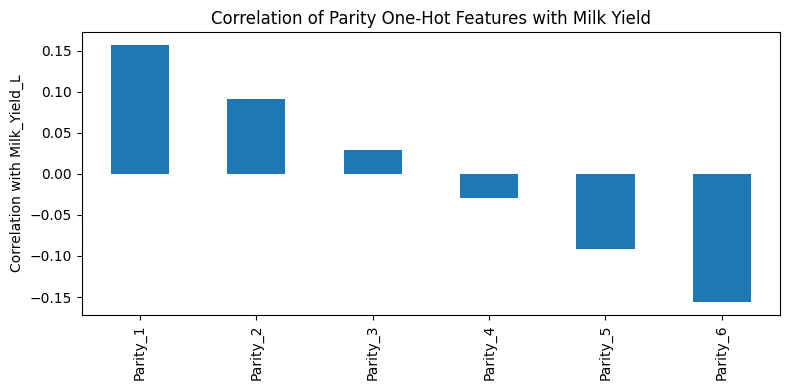

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# Load data
# ======================
data = pd.read_csv("./data/in/cattle_data_train.csv")

TARGET = "Milk_Yield_L"
PARITY = "Parity"

# ======================
# One-hot encode Parity
# ======================
parity_ohe = pd.get_dummies(data[PARITY], prefix="Parity")

# Combine with target
datata = pd.concat([parity_ohe, data[TARGET]], axis=1)

# ======================
# Compute correlation
# ======================
corrs = datata.corr()[TARGET].drop(TARGET)  # drop self-correlation

# ======================
# Plot
# ======================
plt.figure(figsize=(8, 4))
corrs.plot(kind="bar")
plt.ylabel("Correlation with Milk_Yield_L")
plt.title("Correlation of Parity One-Hot Features with Milk Yield")
plt.tight_layout()
plt.show()


### Age Exploration

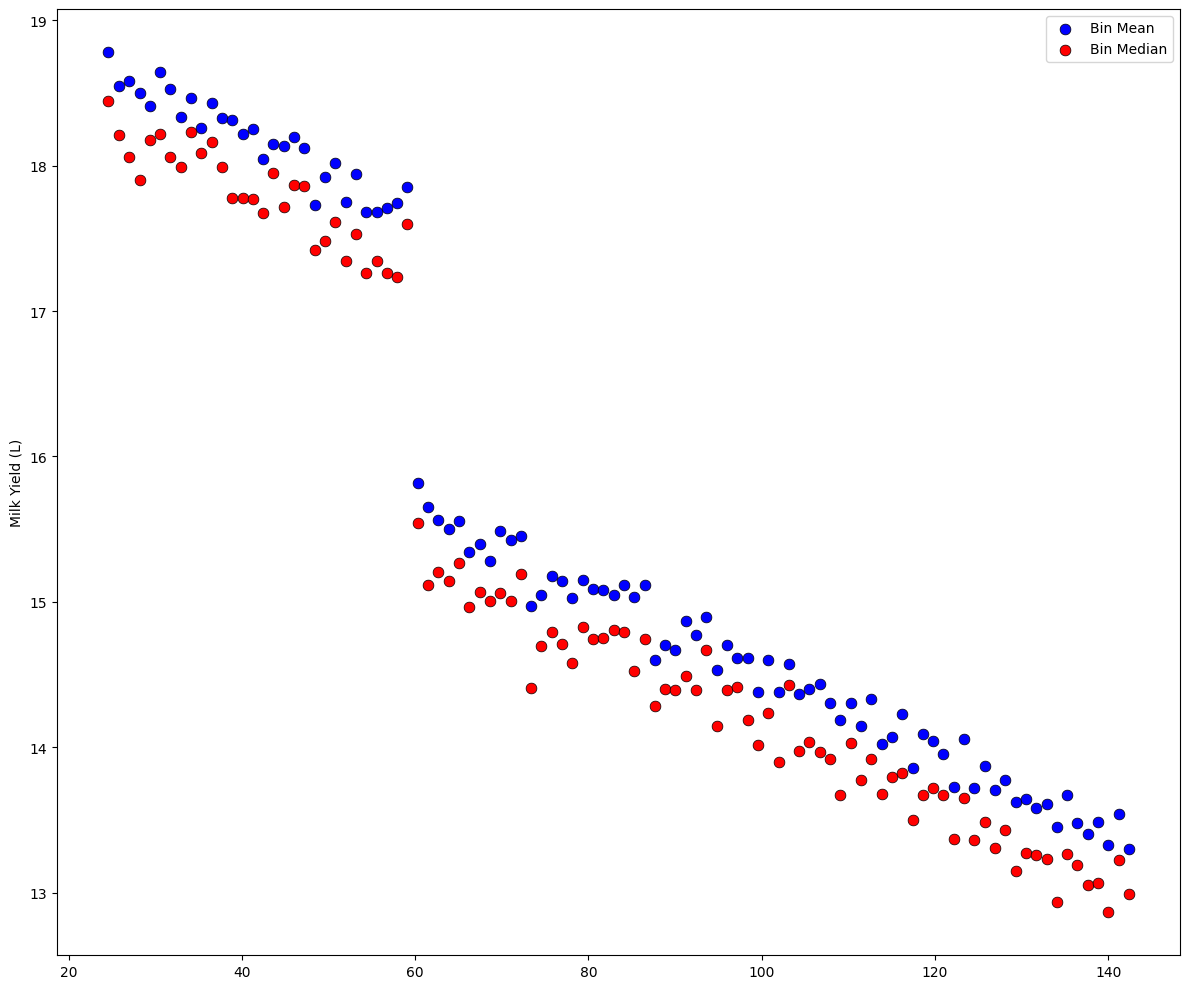

In [30]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Load data
# ======================
data = pd.read_csv("./data/in/cattle_data_train.csv")

TARGET = "Milk_Yield_L"

# Replace ages < 60
data['Age_Months'] = np.where(
    data['Age_Months'] < 60,
    min (data['Age_Months']) - (data['Age_Months'] - 60) - 1,
    data['Age_Months']
)

# Bin into 100 equal-width bins
data['x_bin'] = pd.cut(data['Age_Months'], bins=100)

stats = data.groupby('x_bin', observed=True)[TARGET].agg(
    ['mean', 'median', 'count']
).reset_index()

# Compute bin midpoints
stats['x_mid'] = stats['x_bin'].apply(lambda x: x.mid)

# Create figure with subplots
fig, ax1 = plt.subplots(1, 1, figsize=(12, 10), sharex=True)

# Top scatter
ax1.scatter(stats['x_mid'], stats['mean'], color='blue', 
            label='Bin Mean', s=60, edgecolor='k', linewidth=0.5, zorder=5)
ax1.scatter(stats['x_mid'], stats['median'], color='red', 
            label='Bin Median', s=60, edgecolor='k', linewidth=0.5, zorder=5)
ax1.legend()
ax1.set_ylabel("Milk Yield (L)")

plt.tight_layout()
plt.show()


### Milk Yield Exploration

===== Descriptive Statistics =====
count    210000.000000
mean         15.589156
std           5.352079
min          -5.700324
25%          11.822207
50%          15.145871
75%          18.884708
max          44.555285
Name: Milk_Yield_L, dtype: float64

IQR-based outlier thresholds:
Lower bound: 1.228, Upper bound: 29.478


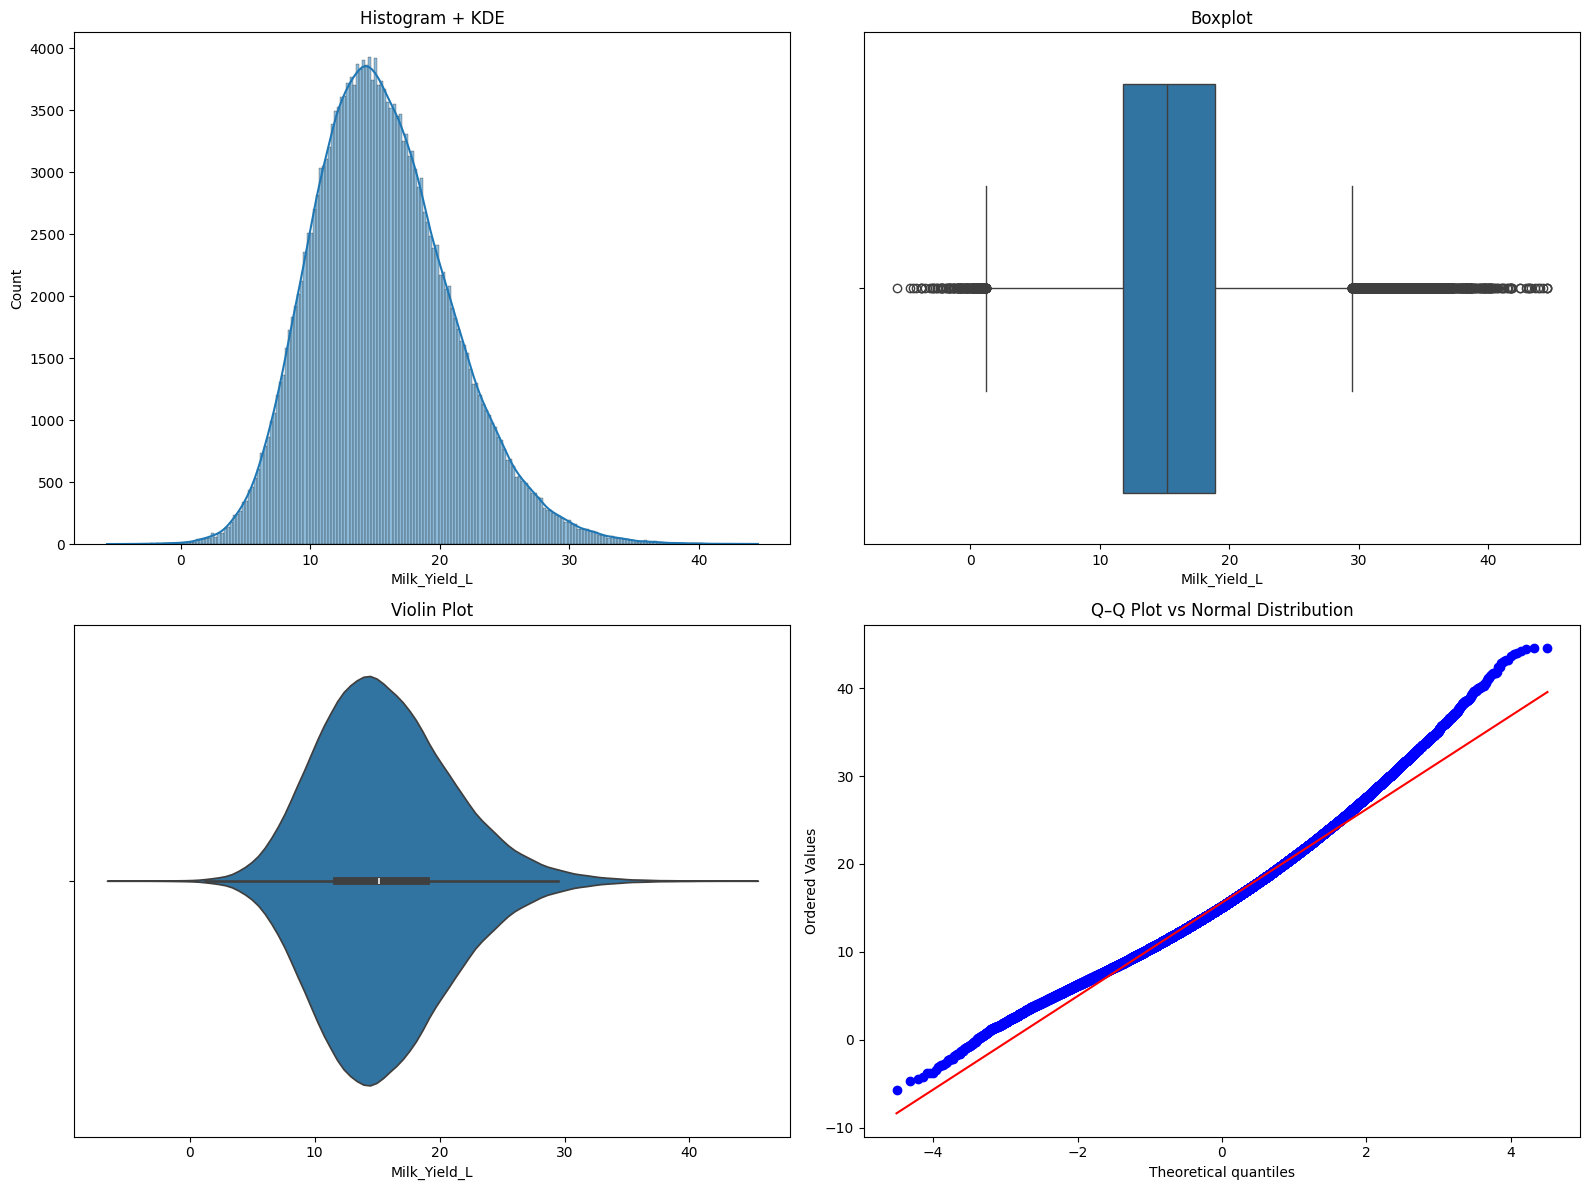

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# --------------------------
# Load data
# --------------------------
data = pd.read_csv("./data/in/cattle_data_train.csv")
TARGET = "Milk_Yield_L"

y = data[TARGET].dropna()

# --------------------------
# Print descriptive stats
# --------------------------
print("===== Descriptive Statistics =====")
print(y.describe())
print("\nIQR-based outlier thresholds:")
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Lower bound: {lower:.3f}, Upper bound: {upper:.3f}")

# --------------------------
# Plot distribution graphs
# --------------------------
plt.figure(figsize=(16, 12))

# Histogram + KDE
plt.subplot(2, 2, 1)
sns.histplot(y, kde=True)
plt.title("Histogram + KDE")

# Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=y)
plt.title("Boxplot")

# Violin plot
plt.subplot(2, 2, 3)
sns.violinplot(x=y)
plt.title("Violin Plot")

# Q-Q plot
plt.subplot(2, 2, 4)
stats.probplot(y, dist="norm", plot=plt)
plt.title("Q–Q Plot vs Normal Distribution")

plt.tight_layout()
plt.show()


### Stress Index Exploration

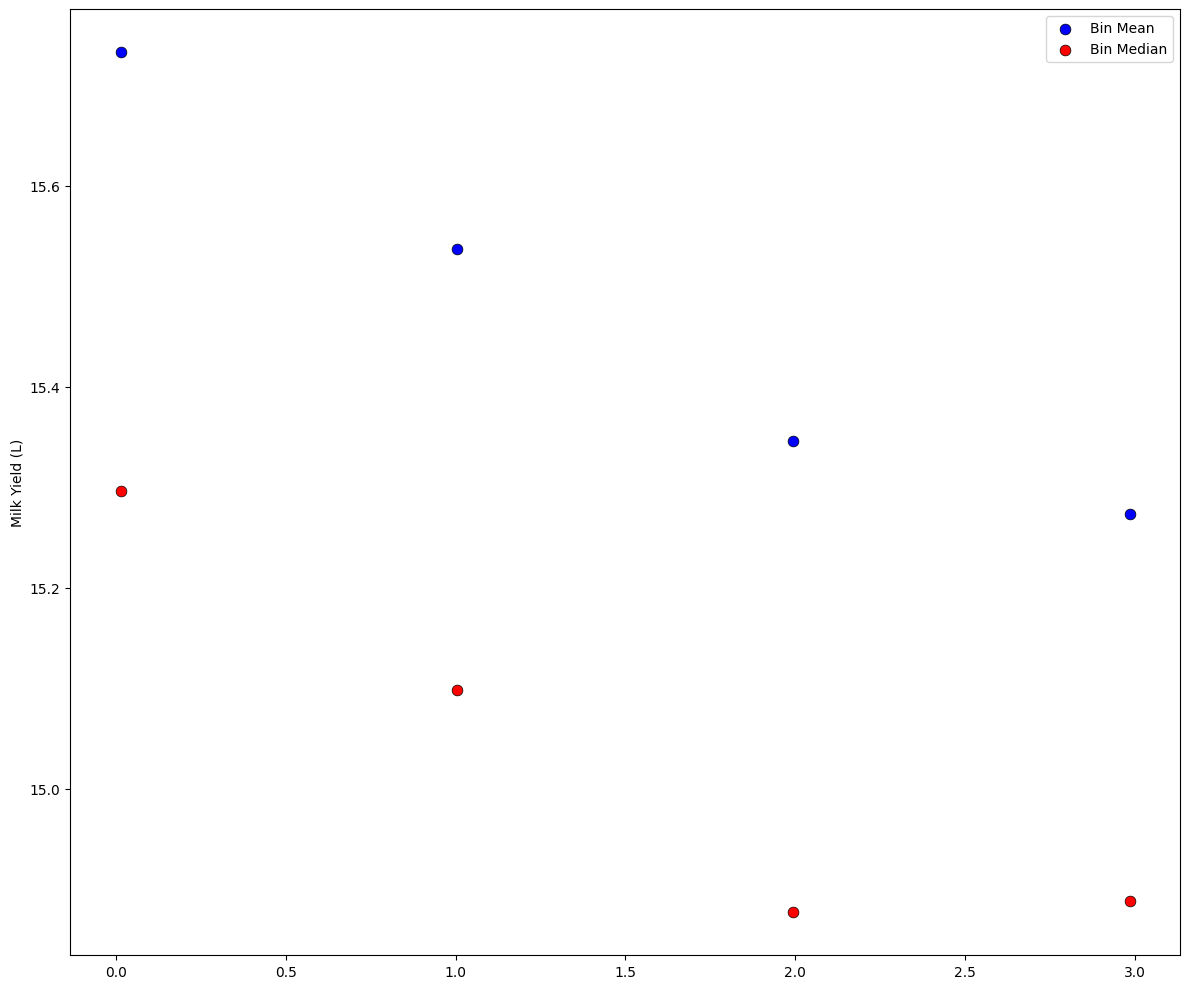

In [45]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Load data
# ======================
data = pd.read_csv("./data/in/cattle_data_train.csv")

TARGET = "Milk_Yield_L"

# Replace ages < 60
data["THI"] = (0.8 * data["Ambient_Temperature_C"]) + \
               (data["Humidity_percent"] / 100) * (data["Ambient_Temperature_C"] - 14.4) + \
               46.4
              
# THI Stress Categories (Armstrong, 1994)
# <72: No Stress, 72-78: Mild, 78-88: Moderate, >88: Severe
data["THI_Stress_Level"] = 0
data.loc[(data["THI"] >= 72) & (data["THI"] < 78), "THI_Stress_Level"] = 1
data.loc[(data["THI"] >= 78) & (data["THI"] < 88), "THI_Stress_Level"] = 2
data.loc[data["THI"] >= 88, "THI_Stress_Level"] = 3

# Bin into 100 equal-width bins
data['x_bin'] = pd.cut(data['THI_Stress_Level'], bins=100)

stats = data.groupby('x_bin', observed=True)[TARGET].agg(
    ['mean', 'median', 'count']
).reset_index()

# Compute bin midpoints
stats['x_mid'] = stats['x_bin'].apply(lambda x: x.mid)

# Create figure with subplots
fig, ax1 = plt.subplots(1, 1, figsize=(12, 10), sharex=True)

# Top scatter
ax1.scatter(stats['x_mid'], stats['mean'], color='blue', 
            label='Bin Mean', s=60, edgecolor='k', linewidth=0.5, zorder=5)
ax1.scatter(stats['x_mid'], stats['median'], color='red', 
            label='Bin Median', s=60, edgecolor='k', linewidth=0.5, zorder=5)
ax1.legend()
ax1.set_ylabel("Milk Yield (L)")

plt.tight_layout()
plt.show()